In [1]:
from time import perf_counter

import numpy as np
from scipy.sparse.linalg import eigsh

import jax
jax.config.update("jax_enable_x64", True)

from jax import numpy as jnp

import equinox as eqx
import optax

from atr.models import RestrictedBoltzmannMachine, param_count
from atr.sampler import SpinSampler
from atr.operator import LocalOperator, operator_expect, operator_expect_and_variance, TransverseFieldIsing
from atr.graph import Cube
from atr.operator.spin import to_dense
from atr.jacobian import natural_gradient
from atr.utils import abs2

import matplotlib.pyplot as plt

## NQS setup

Ground state initialization

In [2]:
N = 12

$$
H = - J \sum _{\langle i j \rangle} \sigma^z _i \sigma^z _j - h \sum _i \sigma^x _i
$$

In [3]:
key = jax.random.PRNGKey(1337)

In [4]:
graph = Cube(N, pbc=True)
H = TransverseFieldIsing(graph, J=0.8, h=1.0)

In [5]:
E0 = eigsh(np.asarray(to_dense(H)), k=1, which='SA', return_eigenvectors=False).item()
E0

-14.021144494312813

In [6]:
logpsi = RestrictedBoltzmannMachine(n_spins=N, alpha=2.0, key=key)

In [7]:
logpsi

_RealWrapper(
  params=RestrictedBoltzmannMachine(
    hidden=Linear(
      weight=ComplexValue(real=f64[24,12], imag=f64[24,12]),
      bias=ComplexValue(real=f64[24], imag=f64[24]),
      in_features=12,
      out_features=24,
      use_bias=True
    ),
    visible=Linear(
      weight=ComplexValue(real=f64[1,12], imag=f64[1,12]),
      bias=None,
      in_features=12,
      out_features='scalar',
      use_bias=False
    ),
    activation=None
  ),
  backbone=RestrictedBoltzmannMachine(
    hidden=Linear(
      weight=None,
      bias=None,
      in_features=12,
      out_features=24,
      use_bias=True
    ),
    visible=Linear(
      weight=None,
      bias=None,
      in_features=12,
      out_features='scalar',
      use_bias=False
    ),
    activation=<function log_cosh>
  )
)

In [8]:
param_count(logpsi)

648

In [9]:
sampler = SpinSampler(dims=N, n_samples=128, n_chains=2)

In [10]:
key, = jax.random.split(key, 1)
samples = sampler(logpsi, key).reshape(-1, N)

In [11]:
operator_expect(H, logpsi, samples)

Array(-10.70282385, dtype=float64)

In [12]:
# optim = optax.adam(1e-3)
# opt_state = optim.init(eqx.filter(logpsi, eqx.is_inexact_array))

# @eqx.filter_jit
# def step(logpsi, opt_state, key):

#     samples = sampler(logpsi, key).reshape(-1, N)

#     @partial(eqx.filter_value_and_grad, has_aux=True)
#     def energy(logpsi):
#         return operator_expect_and_variance(H, logpsi, samples, chunk_size=32)

#     (energy_val, energy_var), grads = energy(logpsi)
#     updates, opt_state = optim.update(grads, opt_state)
#     logpsi = eqx.apply_updates(logpsi, updates)

#     return energy_val, energy_var, logpsi, opt_state

In [13]:
optim = optax.sgd(1e-2)
opt_state = optim.init(eqx.filter(logpsi, eqx.is_array))

@eqx.filter_jit
def step(logpsi, opt_state, key):

    samples = sampler(logpsi, key).reshape(-1, N)

    local_energy = LocalOperator(H, logpsi)
    eloc = jax.vmap(local_energy)(samples)
    
    energy_val = jnp.mean(eloc.real)
    energy_var = jnp.mean(abs2(eloc - energy_val))
    energy_val = jnp.real(energy_val)
    
    grads = natural_gradient(logpsi, samples, eloc, diag_shift=1e-6)

    updates, opt_state = optim.update(grads, opt_state)
    logpsi = eqx.apply_updates(logpsi, updates)

    return energy_val, energy_var, logpsi, opt_state

In [14]:
energies, variances = [], []
clock = perf_counter()
global_clock = perf_counter()

for i in range(500):

    key = jax.random.fold_in(key, i)

    energy, var, logpsi, opt_state = step(logpsi, opt_state, key)

    energies.append(energy.item())
    variances.append(var.item())

    if perf_counter() - clock > 4:
        time_per_step = (perf_counter() - global_clock) / (i + 1)
        print(f"Step {i:4} | Energy: {energy:.4e} | Variance: {var:.4e} | Time per step: {time_per_step:.2f} s")
        clock = perf_counter()

Step   49 | Energy: -1.3641e+01 | Variance: 6.1640e-01 | Time per step: 0.08 s
Step  109 | Energy: -1.3965e+01 | Variance: 6.0253e-02 | Time per step: 0.07 s
Step  168 | Energy: -1.3999e+01 | Variance: 1.2589e-02 | Time per step: 0.07 s
Step  229 | Energy: -1.4023e+01 | Variance: 3.1639e-03 | Time per step: 0.07 s
Step  291 | Energy: -1.4016e+01 | Variance: 9.9537e-04 | Time per step: 0.07 s
Step  353 | Energy: -1.4020e+01 | Variance: 4.0597e-04 | Time per step: 0.07 s
Step  415 | Energy: -1.4019e+01 | Variance: 2.8032e-04 | Time per step: 0.07 s
Step  477 | Energy: -1.4022e+01 | Variance: 1.9749e-04 | Time per step: 0.07 s


Text(0, 0.5, 'Energy')

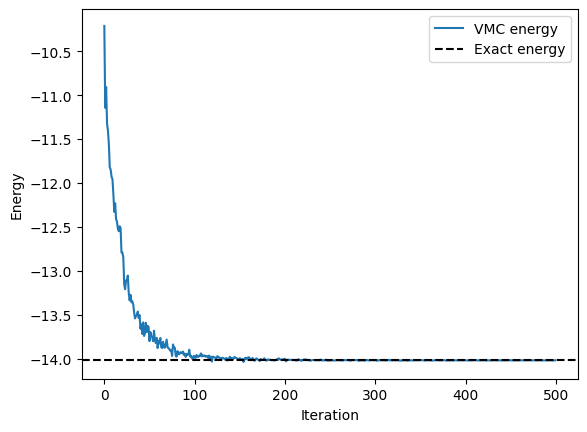

In [15]:
plt.plot(energies, label="VMC energy")
plt.axhline(E0, color="black", linestyle="--", label="Exact energy")
plt.legend()

plt.xlabel("Iteration")
plt.ylabel("Energy")

Text(0, 0.5, 'Variance')

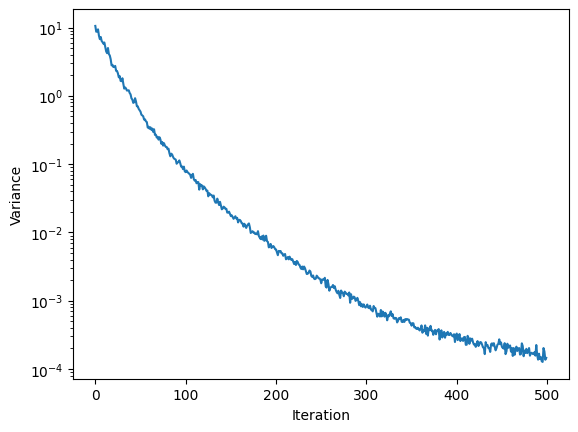

In [16]:
plt.semilogy(variances)
plt.xlabel("Iteration")
plt.ylabel("Variance")